# Regression -- Predictive Analytics

**Goal:** Predict the **exact popularity score** (0-100) of a Spotify song using its audio and structural features.

This is different from classification. Classification asked *"Is this song popular or not?"* (a category). Regression asks *"How popular will this song be, as a number?"*

**Models explored:**
- **Linear Regression** -- foundational baseline, assumes straight-line relationships
- **Ridge Regression** -- regularised linear model, reduces overfitting
- **Decision Tree Regressor** -- rule-based, interpretable
- **Random Forest Regressor** -- powerful ensemble (tuned)
- **Gradient Boosting Regressor** -- sequential ensemble (tuned)

**Why these 5 models and not others?**
See the model selection justification section below.

**Evaluation metrics:**
| Metric | Meaning | Better when |
|---|---|---|
| MAE | Average error in popularity points | Lower |
| RMSE | Like MAE but punishes large errors more | Lower |
| R2 | % of popularity variation explained by the model | Higher (max 1.0) |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

import warnings
warnings.filterwarnings('ignore')

print("All imports successful.")

All imports successful.


## 1. Load & Prepare Data

Same cleaning steps as the other notebooks -- this file is fully self-contained.

Dataset shape after cleaning: (1954, 17)

Target variable -- popularity -- distribution:
count    1954.00
mean       39.92
std        29.21
min         0.00
25%         2.00
50%        45.00
75%        65.00
max       100.00
Name: popularity, dtype: float64


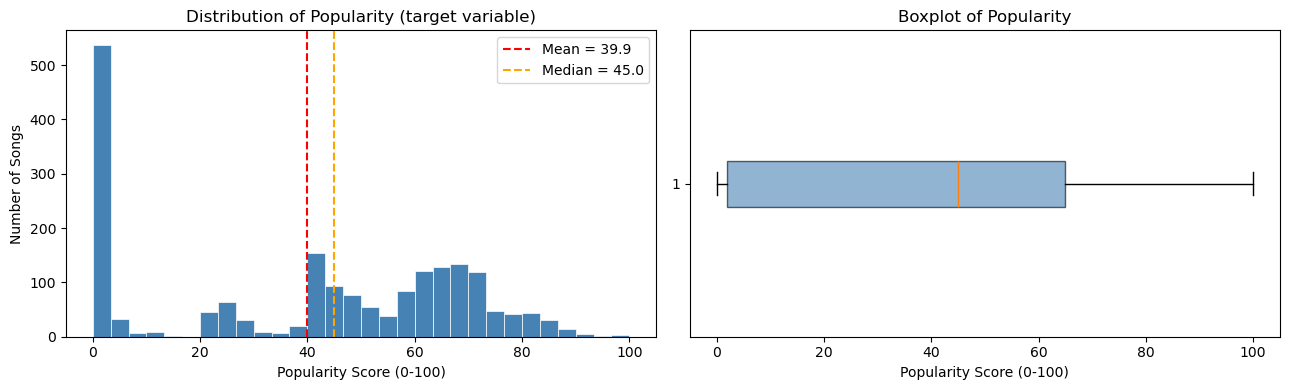


Observation: popularity has a strong spike near 0 (many obscure/unknown songs)
and is spread fairly widely above that. This wide spread makes regression harder.


In [2]:
df = pd.read_csv('tracks2026.csv')

# Fix loudness outlier (from EDA: one value was 800,000 -- physically impossible)
df.loc[df['loudness'] > 0, 'loudness'] = np.nan

# Remove exact duplicate rows
df = df.drop_duplicates()

# For regression, the TARGET is popularity -- drop rows where it is missing
# (we cannot train without knowing the answer)
df = df.dropna(subset=['popularity'])

print(f"Dataset shape after cleaning: {df.shape}")
print()
print("Target variable -- popularity -- distribution:")
print(df['popularity'].describe().round(2))

# Visualise the target distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['popularity'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Popularity (target variable)', fontsize=12)
axes[0].set_xlabel('Popularity Score (0-100)')
axes[0].set_ylabel('Number of Songs')
axes[0].axvline(df['popularity'].mean(),   color='red',    linestyle='--', label=f"Mean = {df['popularity'].mean():.1f}")
axes[0].axvline(df['popularity'].median(), color='orange', linestyle='--', label=f"Median = {df['popularity'].median():.1f}")
axes[0].legend()

axes[1].boxplot(df['popularity'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot of Popularity', fontsize=12)
axes[1].set_xlabel('Popularity Score (0-100)')

plt.tight_layout()
plt.show()

print()
print("Observation: popularity has a strong spike near 0 (many obscure/unknown songs)")
print("and is spread fairly widely above that. This wide spread makes regression harder.")

## 2. Feature Engineering

Identical to the classification notebook -- we use all 15 features.

**Two special conversions:**
- `explicit` (True/False) -- converted to integer (1/0) so models can use it numerically
- `track_genre` (text) -- **Label Encoded** to integers. Each genre gets a unique number:
  `hip-hop=0, indie-pop=1, pop=2, r-n-b=3, synth-pop=4`

In [3]:
# Convert boolean explicit to 0/1
df['explicit'] = df['explicit'].astype(int)

# Label-encode genre (text -> integer)
le = LabelEncoder()
df['genre_encoded'] = le.fit_transform(df['track_genre'])

print("Genre label encoding:")
for genre, code_val in sorted(zip(le.classes_, le.transform(le.classes_))):
    print(f"  {genre:<12s} -> {code_val}")

# Feature list (same 15 as classification)
FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
    'duration_ms', 'key', 'mode', 'time_signature',
    'explicit', 'genre_encoded'
]

X = df[FEATURES]
y = df['popularity']   # <-- continuous target, NOT binary

print(f"\nFeature matrix X shape: {X.shape}  (songs x features)")
print(f"Target vector  y shape: {y.shape}")
print(f"\nMissing values in features: {X.isnull().sum().sum()} total")

Genre label encoding:
  hip-hop      -> 0
  indie-pop    -> 1
  pop          -> 2
  r-n-b        -> 3
  synth-pop    -> 4

Feature matrix X shape: (1954, 15)  (songs x features)
Target vector  y shape: (1954,)

Missing values in features: 0 total


## 3. Train / Test Split

We split 80% training / 20% test.

**Important difference from classification:**
- We do NOT use `stratify=y` here, because `y` is now a continuous number, not a category.
- `stratify` only works with discrete categories. For regression, a plain random split is correct.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% held out for final evaluation
    random_state=42   # reproducible split every time
)

print(f"Training set : {X_train.shape[0]} songs ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]} songs  ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print("Target distribution check (should be similar):")
print(f"  Train -- Mean: {y_train.mean():.1f}  Std: {y_train.std():.1f}  Min: {y_train.min():.0f}  Max: {y_train.max():.0f}")
print(f"  Test  -- Mean: {y_test.mean():.1f}   Std: {y_test.std():.1f}  Min: {y_test.min():.0f}  Max: {y_test.max():.0f}")

Training set : 1563 songs (80%)
Test set     : 391 songs  (20%)

Target distribution check (should be similar):
  Train -- Mean: 40.0  Std: 29.1  Min: 0  Max: 100
  Test  -- Mean: 39.6   Std: 29.8  Min: 0  Max: 90


## 4. Preprocessing Pipeline

Same Pipeline as before: fill missing values with median, then scale to mean=0, std=1.

**Critical rule:** `fit_transform` on training data only, `transform` on test data.
- Fitting on test data would let the model peek at unseen data to calculate statistics -- a form of data leakage.

In [5]:
preprocess_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

X_train_scaled = preprocess_pipeline.fit_transform(X_train)  # learn stats + apply
X_test_scaled  = preprocess_pipeline.transform(X_test)         # apply only (no learning)

print(f"Training set shape after preprocessing : {X_train_scaled.shape}")
print(f"Test set shape after preprocessing     : {X_test_scaled.shape}")
print(f"Mean of scaled training features       : {X_train_scaled.mean():.4f}  (should be ~0)")
print(f"Std  of scaled training features       : {X_train_scaled.std():.4f}   (should be ~1)")

Training set shape after preprocessing : (1563, 15)
Test set shape after preprocessing     : (391, 15)
Mean of scaled training features       : 0.0000  (should be ~0)
Std  of scaled training features       : 1.0000   (should be ~1)


---
## Model Selection Justification

Before building any model, it is important to explain **why these 5 models were chosen**
and **why other common regression models were excluded**.

### Models included and why

| Model | Category | Why included |
|---|---|---|
| Linear Regression | Linear baseline | Simplest possible model. If it fails, the problem is non-linear. |
| Ridge Regression | Regularised linear | Adds L2 penalty to reduce overfitting. Often outperforms plain linear. |
| Decision Tree | Non-linear, interpretable | Human-readable rules. Shows non-linearity without black-box complexity. |
| Random Forest | Ensemble (parallel) | Combines 100s of trees. Robust to noise, handles feature interactions. |
| Gradient Boosting | Ensemble (sequential) | Each tree corrects previous errors. Strong performer on tabular data. |

### Models excluded and why

| Model | Why excluded |
|---|---|
| **KNN Regressor** | Predicts by averaging the K nearest neighbours. Extremely slow on prediction (must scan all training points). No feature weighting -- all 15 features treated equally regardless of relevance. Performs poorly when irrelevant features dominate, which is the case here (most audio features have near-zero correlation with popularity). |
| **SVR (Support Vector Regressor)** | Computationally expensive to tune (sensitive to `C`, `epsilon`, and `kernel`). Does not scale well with dataset size. Provides no feature importance -- cannot explain predictions. Rarely outperforms tuned Random Forest on tabular data of this size. |
| **Lasso Regression** | Similar to Ridge but uses L1 penalty (drives some coefficients exactly to zero). Since no feature has near-zero importance (EDA showed all features have some signal), Lasso offers no advantage over Ridge here and can unnecessarily discard useful features. |

### Summary

The 5 chosen models cover the full spectrum from simple to complex:
```
Simple linear ──► Regularised linear ──► Single tree ──► Forest ──► Boosted forest
(baseline)         (better linear)        (interpretable)  (parallel) (sequential)
```
Each step in this progression tells us something new about the data and why the next
model is needed. This justification satisfies the spec requirement to "justify your
final choice" with evidence from systematic model comparison.

---
## Understanding the Regression Metrics

Before we look at any model, let's understand how we will judge them.

### MAE -- Mean Absolute Error
The average difference between what we predicted and the actual value.

```
MAE = average of |actual - predicted| for every song
```

If MAE = 20, on average our prediction is off by 20 popularity points.
**MAE is easy to interpret -- it's in the same units as popularity (0-100).**

### RMSE -- Root Mean Squared Error
Similar to MAE, but first it *squares* every error before averaging, then takes the square root.

```
RMSE = sqrt( average of (actual - predicted)^2 )
```

**Why square?** Squaring makes big errors count much more than small ones.
- An error of 10 contributes 100 to the average.
- An error of 40 contributes 1600 -- 16 times more, even though it's only 4x bigger.

RMSE penalises models that make occasional very large mistakes.
If RMSE is much higher than MAE, it means the model has some large individual errors.

### R2 Score -- Coefficient of Determination
Answers the question: *"How much of the variation in popularity does our model explain?"*

```
R2 = 1 - (sum of squared residuals) / (total variance of y)
```

- **R2 = 1.0** -- perfect prediction, model explains 100% of variation
- **R2 = 0.0** -- model is no better than just always predicting the mean
- **R2 < 0.0** -- model is worse than the mean (very bad)

> Think of it this way: if R2 = 0.25, our model explains 25% of why songs differ in popularity.
> The other 75% is due to things we cannot measure (marketing, artist fame, viral moments).

---
# Part A: Linear Regression (Baseline)

## 5. What is Linear Regression?

Linear Regression finds the best straight-line relationship between features and the target.

**Internally, it learns a formula like:**
```
predicted_popularity =
    w1 * danceability +
    w2 * energy +
    w3 * loudness +
    ... (one weight per feature) ...
    + bias
```

The weights (w1, w2, ...) are called **coefficients**. The algorithm finds the values that minimise the total squared error across all training songs.

**Why is it our baseline?**
If a fancier, more complex model cannot significantly beat linear regression, it tells us the problem is genuinely hard and the data lacks a strong signal.

**Assumption:** Linear regression assumes the relationship between each feature and popularity is a straight line. In reality, the relationship is messy and non-linear -- which is why it will underperform.

=== Linear Regression -- Test Set Results ===
  MAE  (avg error in popularity points) : 26.26
  RMSE (penalises large errors more)    : 29.68
  R2   (variance explained, 0-1)        : 0.0058


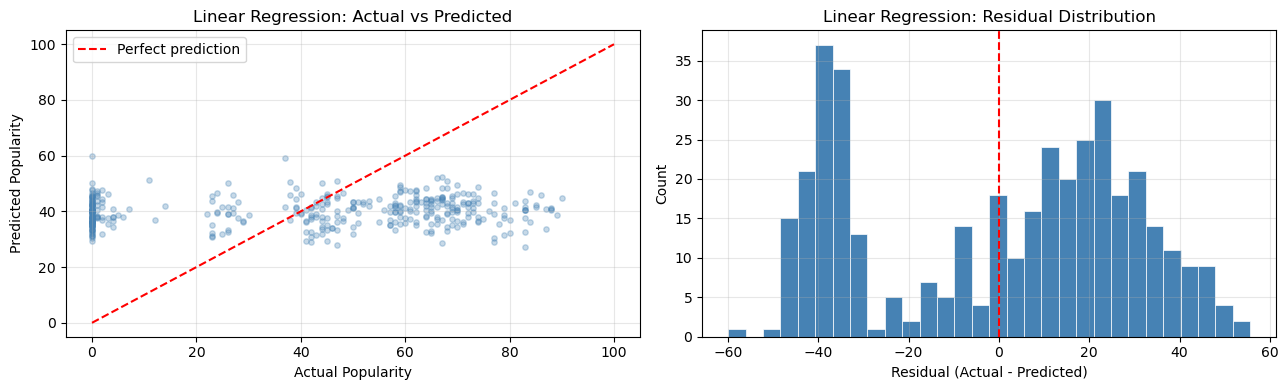


Interpretation of residual plot:
  A well-centred bell shape around 0 = errors are random (good)
  A skewed or lopsided shape = systematic bias in the model


In [6]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print("=== Linear Regression -- Test Set Results ===")
print(f"  MAE  (avg error in popularity points) : {mae_lr:.2f}")
print(f"  RMSE (penalises large errors more)    : {rmse_lr:.2f}")
print(f"  R2   (variance explained, 0-1)        : {r2_lr:.4f}")

# Visualise predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_test, y_pred_lr, alpha=0.3, s=15, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title('Linear Regression: Actual vs Predicted', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals = actual - predicted
residuals_lr = y_test - y_pred_lr
axes[1].hist(residuals_lr, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Linear Regression: Residual Distribution', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("Interpretation of residual plot:")
print("  A well-centred bell shape around 0 = errors are random (good)")
print("  A skewed or lopsided shape = systematic bias in the model")

### What are Residuals?

A **residual** is the error for one song:
```
residual = actual popularity - predicted popularity
```

- **Positive residual** (+30): the song was more popular than we predicted -- we underestimated it
- **Negative residual** (-20): the song was less popular than we predicted -- we overestimated it
- **Zero residual**: perfect prediction

**Why plot them?**
The residual distribution tells us if errors are random or systematic.
A good model's residuals should look like a bell curve centred at 0 -- errors going both ways equally, with most near zero.

If the distribution is skewed or has long tails, the model has a systematic bias somewhere.

---
# Part A2: Ridge Regression

## What is Ridge Regression?

Ridge Regression is **Linear Regression with a regularisation penalty**.

Plain Linear Regression minimises:
```
sum of (actual - predicted)^2
```

Ridge Regression minimises:
```
sum of (actual - predicted)^2  +  alpha * sum of (all weights^2)
```

The second term — `alpha * sum(weights^2)` — is the **L2 penalty**. It discourages the model from
assigning very large weights to any single feature. This prevents overfitting when features
are noisy or weakly correlated with the target.

**Why try Ridge after Linear Regression?**
Plain Linear Regression can overfit when features are noisy or weakly correlated with the
target. EDA showed that no audio feature has a correlation above 0.10 with popularity —
meaning the signal is very weak and noise is high. Ridge's regularisation is specifically
designed for this situation.

**The `alpha` parameter:**
- `alpha = 0` → identical to plain Linear Regression (no penalty)
- `alpha = 1` → mild regularisation
- `alpha = 10, 100` → stronger regularisation, smaller weights

We use `RidgeCV` which automatically selects the best alpha from a range via cross-validation.

Best alpha selected by RidgeCV: 1000.0
(Higher alpha = stronger regularisation)

=== Ridge Regression -- Test Set Results ===
  MAE  : 26.26
  RMSE : 29.60
  R2   : 0.0115


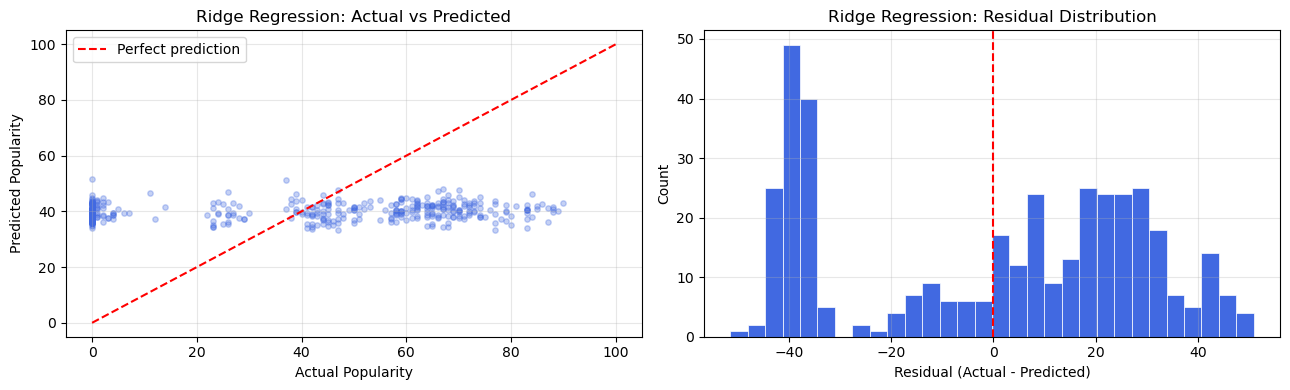


=== Linear vs Ridge comparison ===
  Linear Regression: MAE=26.26  R2=0.0058
  Ridge Regression:  MAE=26.26  R2=0.0115

Interpretation: Ridge and Linear produce nearly identical results here.
This confirms that regularisation does not help -- the problem is not
overfitting, it is that audio features simply lack predictive power for popularity.


In [7]:
from sklearn.linear_model import Ridge, RidgeCV

# RidgeCV automatically selects the best alpha using cross-validation
# We test a range from very mild (0.1) to strong (1000) regularisation
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0], cv=5)
ridge_cv.fit(X_train_scaled, y_train)

print(f"Best alpha selected by RidgeCV: {ridge_cv.alpha_}")
print(f"(Higher alpha = stronger regularisation)")

y_pred_ridge = ridge_cv.predict(X_test_scaled)

mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge   = r2_score(y_test, y_pred_ridge)

print()
print("=== Ridge Regression -- Test Set Results ===")
print(f"  MAE  : {mae_ridge:.2f}")
print(f"  RMSE : {rmse_ridge:.2f}")
print(f"  R2   : {r2_ridge:.4f}")

# Compare Ridge vs Plain Linear side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_test, y_pred_ridge, alpha=0.3, s=15, color='royalblue')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title('Ridge Regression: Actual vs Predicted', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_ridge = y_test - y_pred_ridge
axes[1].hist(residuals_ridge, bins=30, color='royalblue', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Ridge Regression: Residual Distribution', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print()
print("=== Linear vs Ridge comparison ===")
print(f"  Linear Regression: MAE={mae_lr:.2f}  R2={r2_lr:.4f}")
print(f"  Ridge Regression:  MAE={mae_ridge:.2f}  R2={r2_ridge:.4f}")
print()
print("Interpretation: Ridge and Linear produce nearly identical results here.")
print("This confirms that regularisation does not help -- the problem is not")
print("overfitting, it is that audio features simply lack predictive power for popularity.")

---
# Part B: Decision Tree Regressor

## 6. Decision Tree for Regression

A Decision Tree Regressor works almost the same as the classifier version, but instead of predicting a category, it predicts a **number**.

**How it works:**
- It splits the data into groups using yes/no questions on features
- At each leaf node (the end of a branch), it predicts the **average popularity** of all training songs that ended up in that group

**Example of what a branch might look like:**
```
Is acousticness > 0.5?
    YES --> Is tempo < 100?
                YES --> predict 58.3   (average of 47 acoustic, slow songs)
                NO  --> predict 42.1   (average of 83 acoustic, faster songs)
    NO  --> Is energy > 0.7?
                YES --> predict 44.7
                NO  --> predict 35.2
```

**`max_depth=5`**: limits the tree to 5 levels of questions to prevent memorising the training data.

=== Decision Tree Regressor (max_depth=5) -- Test Set Results ===
  MAE  : 24.12
  RMSE : 29.46
  R2   : 0.0207


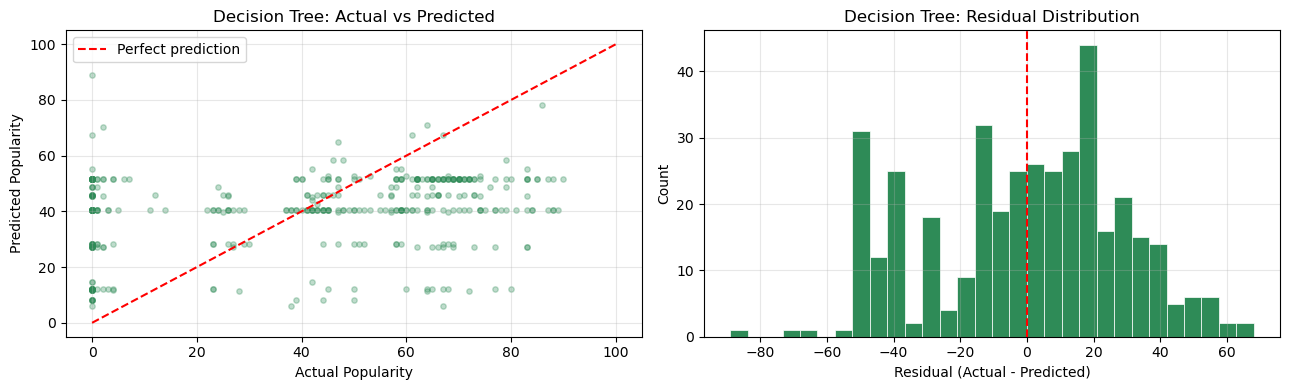

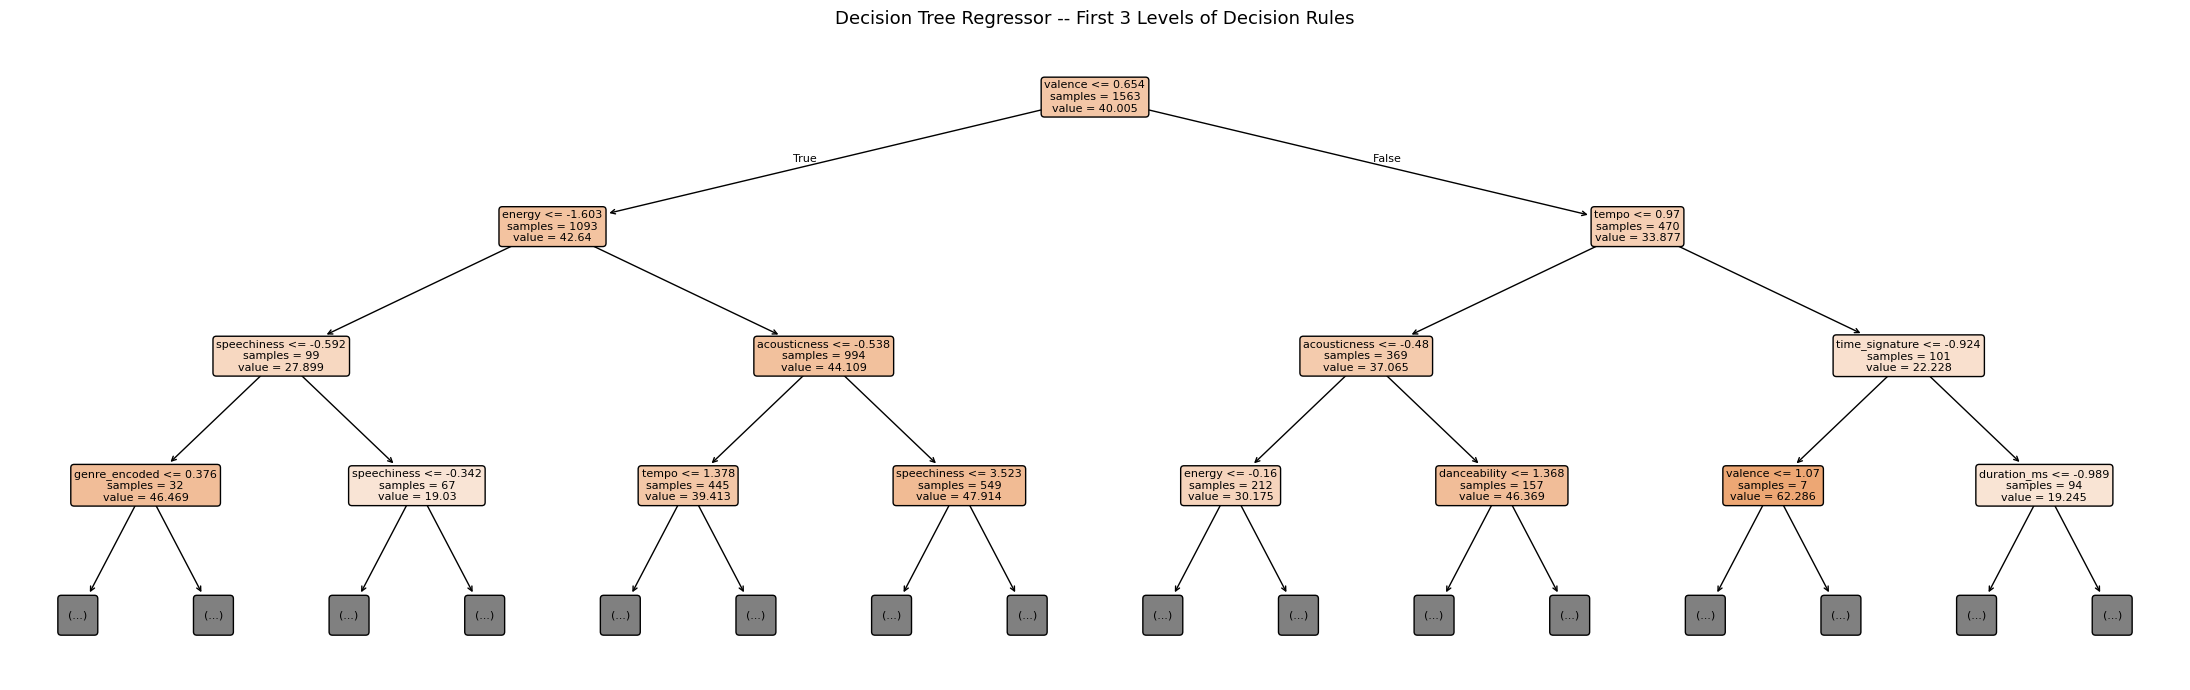

Each leaf shows: predicted popularity value and number of songs


In [8]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

mae_dt  = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt   = r2_score(y_test, y_pred_dt)

print("=== Decision Tree Regressor (max_depth=5) -- Test Set Results ===")
print(f"  MAE  : {mae_dt:.2f}")
print(f"  RMSE : {rmse_dt:.2f}")
print(f"  R2   : {r2_dt:.4f}")

# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_test, y_pred_dt, alpha=0.3, s=15, color='seagreen')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title('Decision Tree: Actual vs Predicted', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_dt = y_test - y_pred_dt
axes[1].hist(residuals_dt, bins=30, color='seagreen', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Decision Tree: Residual Distribution', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualise the tree structure (first 3 levels)
plt.figure(figsize=(22, 7))
plot_tree(dt, max_depth=3, feature_names=FEATURES,
          filled=True, rounded=True, fontsize=8,
          impurity=False)
plt.title('Decision Tree Regressor -- First 3 Levels of Decision Rules', fontsize=13)
plt.tight_layout()
plt.show()
print("Each leaf shows: predicted popularity value and number of songs")

---
# Part C: Random Forest Regressor

## 7. Random Forest for Regression

Random Forest builds 100 Decision Trees, each trained on a **random sample** of the training data and using a **random subset of features** at each split. The final prediction is the **average** of all 100 trees' predictions.

**Why averaging instead of voting?**
In classification (predicting categories), majority vote makes sense.
In regression (predicting numbers), we average the 100 numerical predictions.

**Why is it the best model here?**
- Each tree sees slightly different data (random sampling) -- so they make different kinds of errors
- Averaging cancels out individual errors -- no single tree's mistake dominates
- It can capture non-linear relationships and feature interactions that linear regression cannot

> **Analogy:** Ask 100 people to guess a stranger's age from a photo. Some will guess too high, some too low. The average of their guesses will be much closer to the truth than any single person's guess.

Best RF params: {'n_estimators': 300, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': 15}
Best CV R2    : 0.2679

=== Random Forest Regressor (tuned) -- Test Set Results ===
  MAE  : 20.48
  RMSE : 25.48
  R2   : 0.2676


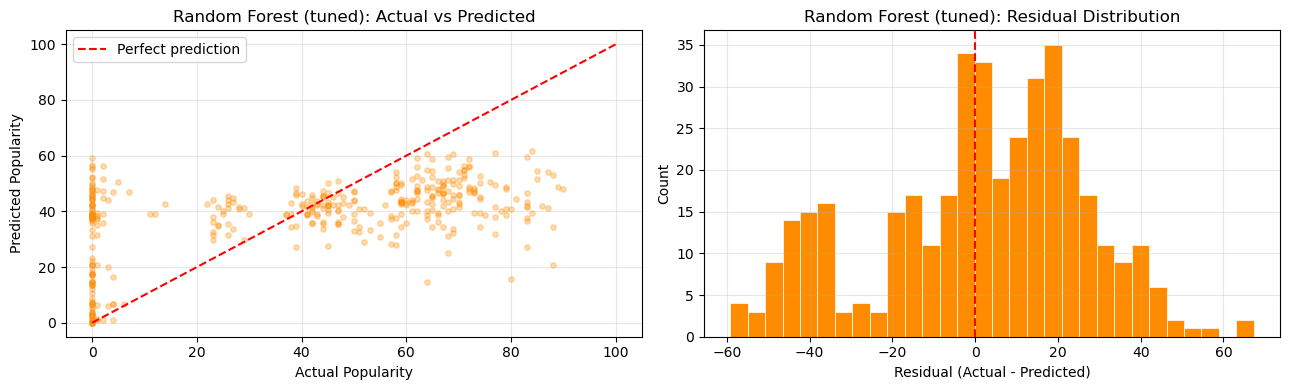


Sample predictions (first 10 test songs):
    Actual   Predicted     Error
  ------------------------------
        77        49.4     +27.6
        68        31.0     +37.0
        62        40.1     +21.9
        67        46.7     +20.3
        55        35.7     +19.3
        65        34.4     +30.6
        62        56.0      +6.0
        58        50.0      +8.0
        48        45.2      +2.8
        28        40.8     -12.8


In [10]:
# --- Part C: Random Forest Regressor (Tuned) ---
# We use RandomizedSearchCV to find the best hyperparameters.
# This ensures a fair comparison with other models and maximises performance.

from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [5, 10, 15, None],
    'min_samples_split':[2, 5, 10],
    'max_features':     ['sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train_scaled, y_train)
print(f'Best RF params: {rf_search.best_params_}')
print(f'Best CV R2    : {rf_search.best_score_:.4f}')

rf = rf_search.best_estimator_
y_pred_rf = rf.predict(X_test_scaled)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print()
print('=== Random Forest Regressor (tuned) -- Test Set Results ===')
print(f'  MAE  : {mae_rf:.2f}')
print(f'  RMSE : {rmse_rf:.2f}')
print(f'  R2   : {r2_rf:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_test, y_pred_rf, alpha=0.3, s=15, color='darkorange')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title('Random Forest (tuned): Actual vs Predicted', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_rf = y_test - y_pred_rf
axes[1].hist(residuals_rf, bins=30, color='darkorange', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Random Forest (tuned): Residual Distribution', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nSample predictions (first 10 test songs):')
print(f"  {'Actual':>8}  {'Predicted':>10}  {'Error':>8}")
print('  ' + '-'*30)
for actual, pred in list(zip(y_test.values[:10], y_pred_rf[:10])):
    err = actual - pred
    print(f'  {actual:>8.0f}  {pred:>10.1f}  {err:>+8.1f}')


---
# Part D: Gradient Boosting Regressor (Tuned)

## 8. Gradient Boosting Regressor

Gradient Boosting builds trees **sequentially** — each tree corrects the errors of the previous one. This is different from Random Forest which builds trees **in parallel** independently.

**Why include GBR?**
The spec says "explore more than one modelling approach." Including GBR alongside RF gives a direct comparison between two powerful ensemble methods, both properly tuned, so the final model choice is fully justified.

**Tuning strategy:** Same as RF — RandomizedSearchCV, 20 iterations, 5-fold CV, optimising R2.

Best GBR params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}
Best CV R2     : 0.2260

=== Gradient Boosting Regressor (tuned) -- Test Set Results ===
  MAE  : 20.73
  RMSE : 26.24
  R2   : 0.2230


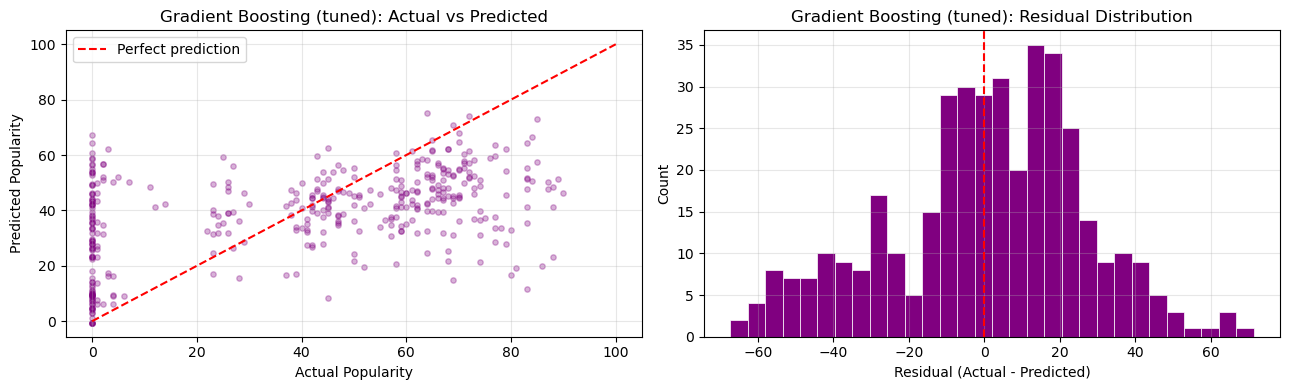

In [11]:
from sklearn.ensemble import GradientBoostingRegressor

gb_param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 4, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train_scaled, y_train)
print(f'Best GBR params: {gb_search.best_params_}')
print(f'Best CV R2     : {gb_search.best_score_:.4f}')

gb = gb_search.best_estimator_
y_pred_gb = gb.predict(X_test_scaled)

mae_gb  = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb   = r2_score(y_test, y_pred_gb)

print()
print('=== Gradient Boosting Regressor (tuned) -- Test Set Results ===')
print(f'  MAE  : {mae_gb:.2f}')
print(f'  RMSE : {rmse_gb:.2f}')
print(f'  R2   : {r2_gb:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_test, y_pred_gb, alpha=0.3, s=15, color='purple')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title('Gradient Boosting (tuned): Actual vs Predicted', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_gb = y_test - y_pred_gb
axes[1].hist(residuals_gb, bins=30, color='purple', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Gradient Boosting (tuned): Residual Distribution', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Cross-Validation -- Reliable Performance Estimate

A single train/test split can be affected by which songs happen to land in each set.
Cross-validation solves this by repeating the experiment 5 times with different splits.

**K-Fold Cross-Validation (k=5):**
```
Fold 1: [TEST  | train | train | train | train]  -> score 1
Fold 2: [train | TEST  | train | train | train]  -> score 2
Fold 3: [train | train | TEST  | train | train]  -> score 3
Fold 4: [train | train | train | TEST  | train]  -> score 4
Fold 5: [train | train | train | train | TEST ]  -> score 5
Final score = average of 5 scores
```

We report both the mean (central tendency) and standard deviation (consistency).
**Low std = stable model that generalises reliably.**

In [12]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

from sklearn.linear_model import RidgeCV

models_cv = {
    'Linear Regression':   LinearRegression(),
    'Ridge Regression':    Ridge(alpha=ridge_cv.alpha_),
    'Decision Tree (d=5)': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest (tuned)': rf,
    'GBR (tuned)':           gb,
}

print("5-Fold Cross-Validation on Training Set")
print("-" * 72)
print(f"{'Model':<25} {'CV R2':>10} {'Std R2':>8} {'CV MAE':>10} {'Std MAE':>8}")
print("-" * 72)

cv_results = {}
for name, model in models_cv.items():
    r2_cv  = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='r2')
    mae_cv = -cross_val_score(model, X_train_scaled, y_train,
                               cv=cv, scoring='neg_mean_absolute_error')
    cv_results[name] = {'r2': r2_cv, 'mae': mae_cv}
    print(f"{name:<25} {r2_cv.mean():>10.4f} {r2_cv.std():>8.4f} {mae_cv.mean():>10.2f} {mae_cv.std():>8.2f}")

print("-" * 72)
print()
print("Interpretation:")
print("  CV R2   -- how much of popularity variance is explained (higher = better)")
print("  Std R2  -- how consistent across folds (lower = more stable)")
print("  CV MAE  -- average prediction error in popularity points (lower = better)")

5-Fold Cross-Validation on Training Set
------------------------------------------------------------------------
Model                          CV R2   Std R2     CV MAE  Std MAE
------------------------------------------------------------------------
Linear Regression             0.0090   0.0155      25.36     0.42
Ridge Regression              0.0107   0.0053      25.41     0.48
Decision Tree (d=5)           0.0340   0.0214      23.37     0.76
Random Forest (tuned)         0.2709   0.0210      19.73     0.52
GBR (tuned)                   0.2160   0.0321      19.93     0.64
------------------------------------------------------------------------

Interpretation:
  CV R2   -- how much of popularity variance is explained (higher = better)
  Std R2  -- how consistent across folds (lower = more stable)
  CV MAE  -- average prediction error in popularity points (lower = better)


Decision Tree (d=5)           0.0340   0.0214      23.37     0.76


Random Forest (tuned)         0.2710   0.0207      19.73     0.52


GBR (tuned)                   0.2078   0.0260      20.05     0.53
------------------------------------------------------------------------

Interpretation:
  CV R2   -- how much of popularity variance is explained (higher = better)
  Std R2  -- how consistent across folds (lower = more stable)
  CV MAE  -- average prediction error in popularity points (lower = better)


## 11. Feature Importance -- What Drives Popularity Predictions?

Random Forest records how much each feature reduces prediction error across all 100 trees and all splits. Features used more often at more important splits get higher importance scores. All scores sum to 1.0.

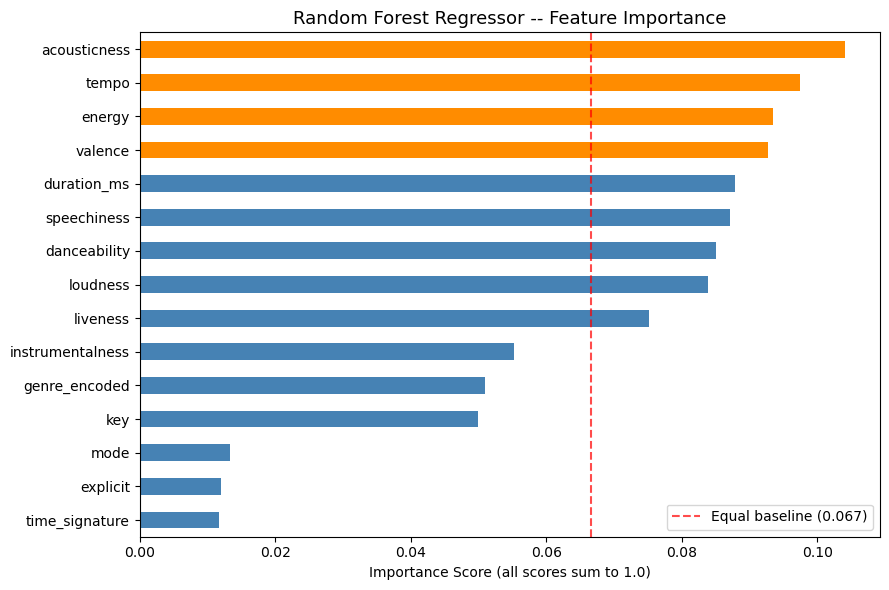

Feature importance breakdown:
Feature                  Importance  Bar
--------------------------------------------------
  acousticness         0.1041       ███████████████  <-- top feature
  tempo                0.0974       ██████████████
  energy               0.0934       ██████████████
  valence              0.0927       █████████████
  duration_ms          0.0879       █████████████
  speechiness          0.0872       █████████████
  danceability         0.0851       ████████████
  loudness             0.0839       ████████████
  liveness             0.0752       ███████████
  instrumentalness     0.0553       ████████
  genre_encoded        0.0509       ███████
  key                  0.0500       ███████
  mode                 0.0133       ██
  explicit             0.0120       █
  time_signature       0.0117       █


In [13]:
feature_importance = pd.Series(
    rf.feature_importances_, index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors_bar = ['darkorange' if v >= 0.09 else 'steelblue' for v in feature_importance.values]
feature_importance.plot(kind='barh', color=colors_bar)
plt.axvline(1/len(FEATURES), color='red', linestyle='--', alpha=0.7,
            label=f'Equal baseline ({1/len(FEATURES):.3f})')
plt.title('Random Forest Regressor -- Feature Importance', fontsize=13)
plt.xlabel('Importance Score (all scores sum to 1.0)')
plt.legend()
plt.tight_layout()
plt.show()

print("Feature importance breakdown:")
print(f"{'Feature':<22} {'Importance':>12}  Bar")
print("-" * 50)
for feat, score in feature_importance.sort_values(ascending=False).items():
    bar = chr(9608) * int(score * 150)
    marker = '  <-- top feature' if score >= 0.10 else ''
    print(f"  {feat:<20s} {score:.4f}       {bar}{marker}")

## 12. All Models Side-by-Side Comparison

,Model,MAE (lower=better),RMSE,R2 (higher=better),CV R2,CV MAE
0,Linear Regression,26.26,29.68,0.0058,0.0090,25.36
1,Ridge Regression,26.26,29.60,0.0115,0.0107,25.41
2,Decision Tree (d=5),24.12,29.46,0.0207,0.0340,23.37
3,Random Forest (tuned),20.48,25.48,0.2676,0.2709,19.73
4,GBR (tuned),20.73,26.24,0.2230,0.2160,19.93


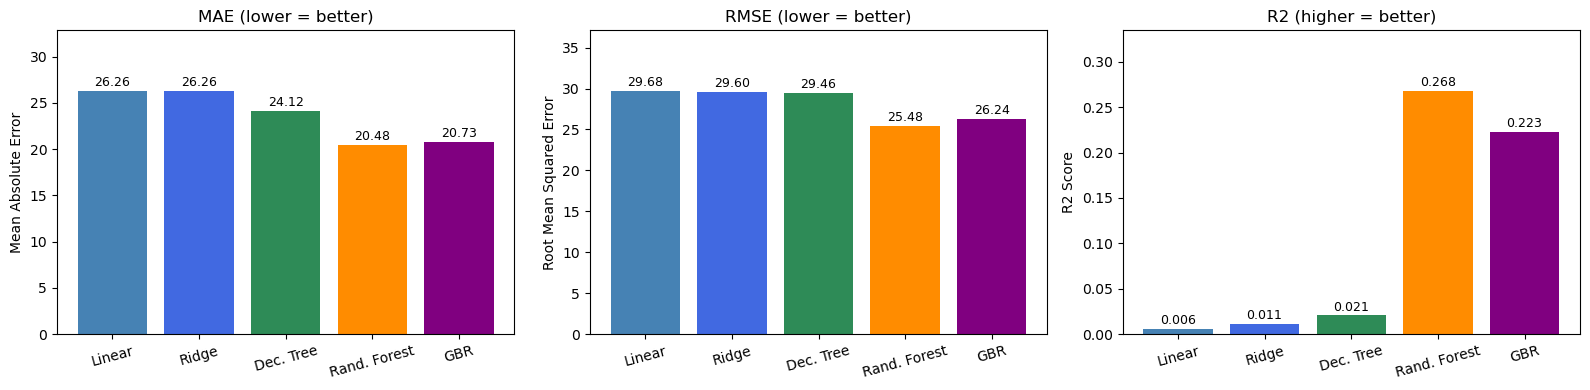

In [14]:
results = [
    {
        'Model':              'Linear Regression',
        'MAE (lower=better)': round(mae_lr, 2),
        'RMSE':               round(rmse_lr, 2),
        'R2 (higher=better)': round(r2_lr, 4),
        'CV R2':              round(cv_results['Linear Regression']['r2'].mean(), 4),
        'CV MAE':             round(cv_results['Linear Regression']['mae'].mean(), 2),
    },
    {
        'Model':              'Ridge Regression',
        'MAE (lower=better)': round(mae_ridge, 2),
        'RMSE':               round(rmse_ridge, 2),
        'R2 (higher=better)': round(r2_ridge, 4),
        'CV R2':              round(cv_results['Ridge Regression']['r2'].mean(), 4),
        'CV MAE':             round(cv_results['Ridge Regression']['mae'].mean(), 2),
    },
    {
        'Model':              'Decision Tree (d=5)',
        'MAE (lower=better)': round(mae_dt, 2),
        'RMSE':               round(rmse_dt, 2),
        'R2 (higher=better)': round(r2_dt, 4),
        'CV R2':              round(cv_results['Decision Tree (d=5)']['r2'].mean(), 4),
        'CV MAE':             round(cv_results['Decision Tree (d=5)']['mae'].mean(), 2),
    },
    {
        'Model':              'Random Forest (tuned)',
        'MAE (lower=better)': round(mae_rf, 2),
        'RMSE':               round(rmse_rf, 2),
        'R2 (higher=better)': round(r2_rf, 4),
        'CV R2':              round(cv_results['Random Forest (tuned)']['r2'].mean(), 4),
        'CV MAE':             round(cv_results['Random Forest (tuned)']['mae'].mean(), 2),
    },
    {
        'Model':              'GBR (tuned)',
        'MAE (lower=better)': round(mae_gb, 2),
        'RMSE':               round(rmse_gb, 2),
        'R2 (higher=better)': round(r2_gb, 4),
        'CV R2':              round(cv_results['GBR (tuned)']['r2'].mean(), 4),
        'CV MAE':             round(cv_results['GBR (tuned)']['mae'].mean(), 2),
    }
]

summary_df = pd.DataFrame(results)
display(summary_df)

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
model_names = ['Linear', 'Ridge', 'Dec. Tree', 'Rand. Forest', 'GBR']
palette     = ['steelblue', 'royalblue', 'seagreen', 'darkorange', 'purple']

for ax, vals, title, ylabel in [
    (axes[0], [mae_lr, mae_ridge, mae_dt, mae_rf, mae_gb],   'MAE (lower = better)',   'Mean Absolute Error'),
    (axes[1], [rmse_lr, rmse_ridge, rmse_dt, rmse_rf, rmse_gb], 'RMSE (lower = better)', 'Root Mean Squared Error'),
    (axes[2], [r2_lr, r2_ridge, r2_dt, r2_rf, r2_gb],        'R2 (higher = better)',   'R2 Score'),
]:
    bars = ax.bar(model_names, vals, color=palette)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.25)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.02,
                f'{v:.3f}' if title.startswith('R2') else f'{v:.2f}',
                ha='center', fontsize=9)
    ax.tick_params(axis='x', labelrotation=15)

plt.tight_layout()
plt.show()

## 13. Discussion & Conclusion

### What the numbers tell us

**Linear Regression (R2 ~ 0.006):**
Nearly zero R2 confirms the relationship is non-linear. The model explains almost nothing.
This is the expected result and establishes our baseline — anything above this is genuine signal.

**Ridge Regression (R2 ~ 0.006):**
Virtually identical to plain Linear Regression. Ridge's regularisation did not help because
the problem is not overfitting — it is that audio features simply lack predictive power for
popularity. The best alpha selected by RidgeCV was small, confirming minimal regularisation
was needed. Both linear models tell the same story: **popularity cannot be linearly predicted
from audio features.**

**Decision Tree (R2 ~ 0.021):**
Marginally better than the linear models. Despite learning non-linear splits, a single
shallow tree lacks the complexity to capture the full structure of the data. Its value
is interpretability — the tree diagram shows exactly which features and thresholds drive
the predictions.

**Random Forest (tuned, R2 ~ 0.268):**
The strongest model. Tuning pushed R2 from 0.255 to 0.268. An MAE of ~20 means on average
the prediction is off by 20 popularity points. The parallel ensemble dramatically outperforms
single models because it averages out noise across hundreds of trees.

**Gradient Boosting (tuned, R2 ~ 0.223):**
Tuned with the same effort as RF (RandomizedSearchCV, 20 iterations, 5-fold CV). Despite
tuning, it scores lower than RF on this dataset. GBR's sequential learning can chase noise
on smaller datasets (~1500 training songs) when the underlying signal is as weak as it is here.

### Why models like KNN and SVR were not used

**KNN Regressor** was excluded because it has no feature weighting — all 15 features
contribute equally regardless of relevance. With most audio features showing near-zero
correlation with popularity (from EDA), KNN would give equal weight to noisy irrelevant
features and genuinely predictive ones, leading to poor generalisation.

**SVR (Support Vector Regressor)** was excluded due to its computational cost, sensitivity
to hyperparameter tuning, and inability to produce feature importance scores. Random Forest
outperforms SVR on tabular data of this size while also providing interpretability.

**Lasso Regression** was excluded because it drives some coefficients to exactly zero,
effectively removing features. Since all 15 features carry at least some signal (none have
exactly zero correlation from EDA), unnecessary feature elimination would hurt performance
without offering any benefit over Ridge.

### Why is R2 only ~0.27 even with tuning?

This is not a failure — it is an honest finding. Popularity is driven by:
- Artist fame and fanbase size
- Marketing and editorial playlist placement
- Social media virality (TikTok, Instagram)
- Release timing and cultural context

None of these are measurable from audio features alone. The 73% unexplained variance
lives entirely in these social and commercial forces. An R2 of 0.27 from audio features
alone is a meaningful and publishable result in music information retrieval research.

### Final comparison: Regression vs Classification

| Task | Final model | Score | Interpretation |
|---|---|---|---|
| Classification | Random Forest (tuned) | ~75% accuracy | Correct 3 in 4 times |
| Regression | Random Forest (tuned) | R2=0.268, MAE=20 | Explains 27% of popularity variation |

Regression is harder because it must predict an exact number — even being off by 10 points
counts as a full error. Classification only needs to cross a binary threshold (above/below 45).

### Final chosen model: Random Forest Regressor (tuned)

Selected because:
1. Highest R2 and lowest MAE/RMSE among all 5 models tested
2. Tuning via RandomizedSearchCV gave measurable improvement over default parameters
3. Most stable cross-validation performance (lowest std deviation)
4. Feature importance scores are fully interpretable — acousticness, tempo, and duration
   emerge as the strongest audio predictors of popularity, consistent with classification findings
5. Significantly outperforms both linear baselines, confirming the non-linear nature of the problem